## Pizza Place Sales Analysis




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [12]:
# Load datasets
orders       = pd.read_csv('orders.csv')
order_details= pd.read_csv('order_details.csv')
pizzas       = pd.read_csv('pizzas.csv')
pizza_types  = pd.read_csv('pizza_types.csv', encoding='latin-1')


orders['date'] = pd.to_datetime(orders['date'])
orders['time'] = pd.to_datetime(orders['time'], format='%H:%M:%S').dt.time

In [13]:
# Joining all datasets into a DataFrame
df = (order_details.merge(orders, on='order_id').merge(pizzas, on='pizza_id').merge(pizza_types,  on='pizza_type_id'))

#columns
df['revenue']    = df['quantity'] * df['price']
df['hour']       = pd.to_datetime(df['time'].astype(str)).dt.hour
df['day_of_week']= df['date'].dt.day_name()
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')

df.head()

C:\Users\Akinwale Emmanuel\AppData\Local\Temp\ipykernel_8216\500914350.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour']       = pd.to_datetime(df['time'].astype(str)).dt.hour


,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,hour,day_of_week,month,month_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,1,January
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,1,January
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,1,January
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,1,January
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,1,January


## Metrics

In [14]:
total_revenue   = df['revenue'].sum()
total_qty       = df['quantity'].sum()
total_orders    = orders['order_id'].nunique()
num_pizza_types = pizza_types['pizza_type_id'].nunique()
avg_price       = pizzas['price'].mean()

metrics = {
    'Total Revenue':    f'${total_revenue:,.2f}',
    'Total Qty Sold':   f'{total_qty:,}',
    'Total Orders':     f'{total_orders:,}',
    'Pizza Types':      f'{num_pizza_types}',
    'Avg Pizza Price':  f'${avg_price:.2f}',
}

for k, v in metrics.items():
    print(f'{k:20s}: {v}')

Total Revenue       : $817,860.05
Total Qty Sold      : 49,574
Total Orders        : 21,350
Pizza Types         : 32
Avg Pizza Price     : $16.44


#### Key Metrics
1. The pizza place generated $817,860.05 in revenue
2. 49,574 pizzas were sold
3. A total of 21,350 orders 
4. The pizza place sold 32 types of pizzas
5. The average cost of pizza was $16.44

Peak Hours of Sales

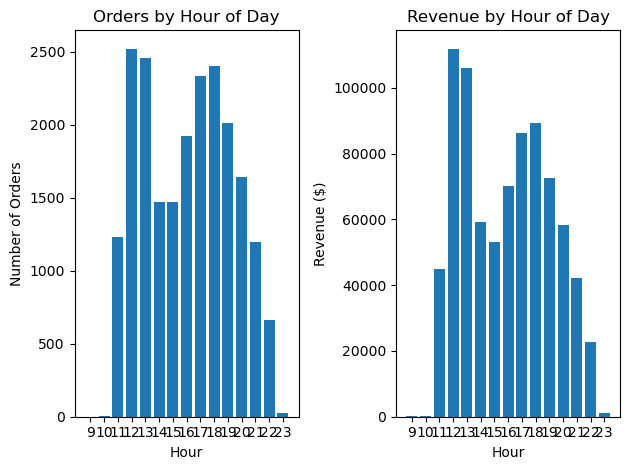

In [15]:
hourly = df.groupby('hour').agg(orders=('order_id','nunique'), revenue=('revenue','sum')).reset_index()

fig, axes = plt.subplots(1, 2,)

axes[0].bar(hourly['hour'], hourly['orders'])
axes[0].set_title('Orders by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticks(hourly['hour'])

axes[1].bar(hourly['hour'], hourly['revenue'])
axes[1].set_title('Revenue by Hour of Day',)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xticks(hourly['hour'])

plt.tight_layout()
plt.savefig('peak_hours.png')
plt.show()

6. 12pm and 1pm consecutively aere the peak hours in the afternoo while 5pm and 6pm are the peak hours in the evening


## Sales by Day of the Week

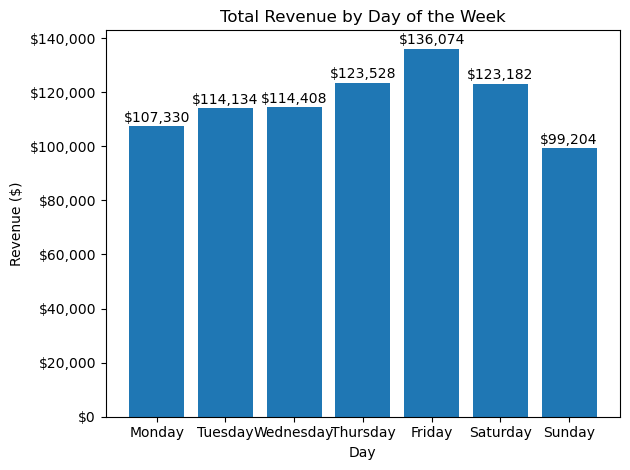

In [16]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = (df.groupby('day_of_week')
           .agg(revenue=('revenue','sum'), orders=('order_id','nunique'))
           .reindex(day_order)
           .reset_index())

fig, ax = plt.subplots()
bars = ax.bar(daily['day_of_week'], daily['revenue'])
ax.set_title('Total Revenue by Day of the Week')
ax.set_xlabel('Day')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'${bar.get_height():,.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('daily_sales.png')
plt.show()



7. Insights on sales from each week day

    * Monday: $107,300
    * Tuesday: $114,134
    * Wednesday: $114,408
    * Thursday: $123,538
    * Friday: $136,074
    * Saturday: $123,182
    * Sunday: $99,204

    Friday has the most sales per day 

## Bestselling Pizzas

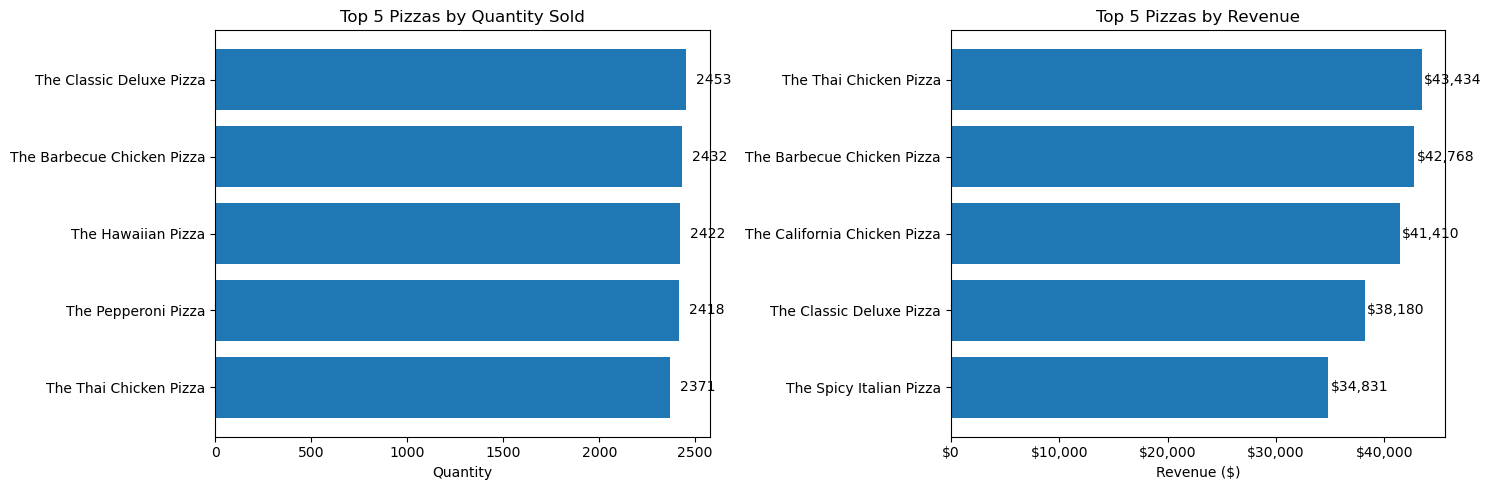

In [17]:
top5_qty = (df.groupby('name')['quantity'].sum()
              .sort_values(ascending=False)
              .head(5)
              .reset_index())

top5_rev = (df.groupby('name')['revenue'].sum()
              .sort_values(ascending=False)
              .head(5)
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By quantity
axes[0].barh(top5_qty['name'][::-1], top5_qty['quantity'][::-1])
axes[0].set_title('Top 5 Pizzas by Quantity Sold')
axes[0].set_xlabel('Quantity')
for i, v in enumerate(top5_qty['quantity'][::-1]):
    axes[0].text(v+50, i, str(v), va='center')

# By revenue
axes[1].barh(top5_rev['name'][::-1], top5_rev['revenue'][::-1])
axes[1].set_title('Top 5 Pizzas by Revenue')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, v in enumerate(top5_rev['revenue'][::-1]):
    axes[1].text(v+200, i, f'${v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('top5_pizzas.png')
plt.show()

8. Top 5 best selling pizza
    - Based on revenue:
        * The classic deluxe pizza
        * The Barbecue pizza 
        * The Hawaiian pizza
        * The pepperoni pizza
        * The thai pizza

    - Based on sales:
        * The thai pizza
        * The Barbecue pizza 
        * The california chicken pizza
        * The classic deluxe pizza
        * The spicy italian pizza


## Monthly Sales Trend

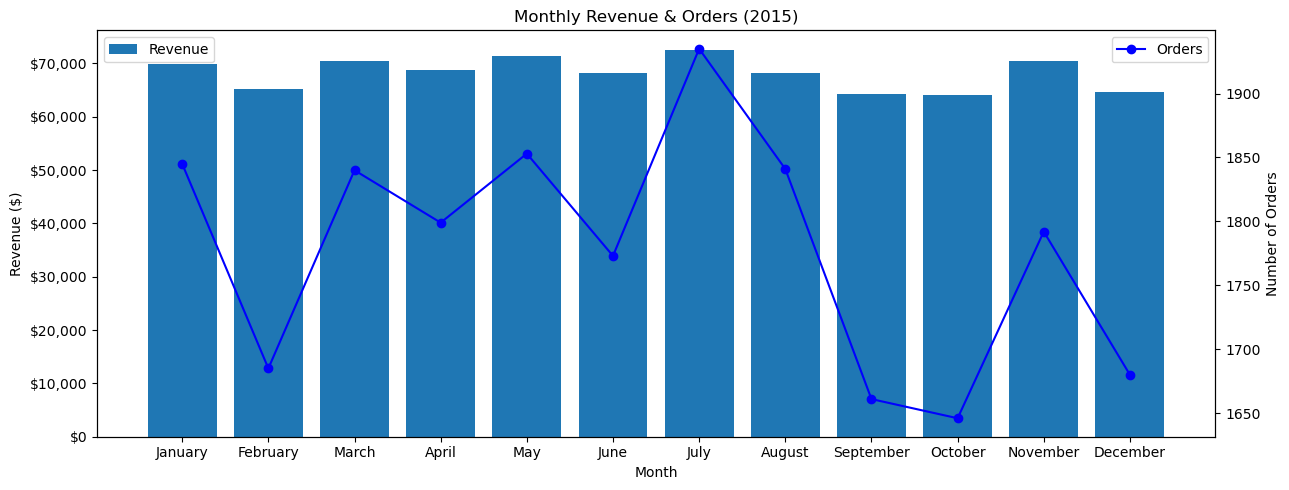

In [18]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = (df.groupby(['month','month_name'])
             .agg(revenue=('revenue','sum'), orders=('order_id','nunique'))
             .reset_index()
             .sort_values('month'))

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month_name'], monthly['revenue'],  label='Revenue')
ax2.plot(monthly['month_name'], monthly['orders'], color="blue", marker='o', label='Orders')

ax1.set_title('Monthly Revenue & Orders (2015)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)')
ax2.set_ylabel('Number of Orders')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=45)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

9. Monthly Trend
    - July is the peak month in terms of both revenue and orders
    - Revenue is fairly consistent across the year
    - October and November has a slight dip.
    - This overall is a healthy, all year round business.

## Underperforming Pizzas

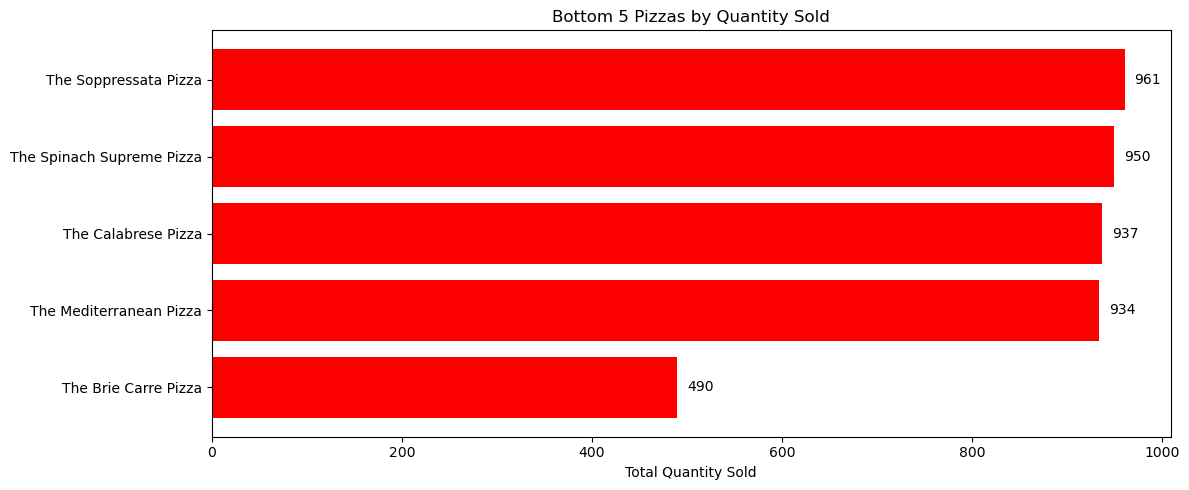

In [19]:
pizza_perf = (df.groupby('name')
                .agg(quantity=('quantity','sum'), revenue=('revenue','sum'))
                .sort_values('quantity'))

bottom10 = pizza_perf.head(5).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(bottom10['name'], bottom10['quantity'], color="red")
ax.set_title('Bottom 5 Pizzas by Quantity Sold')
ax.set_xlabel('Total Quantity Sold')
for i, v in enumerate(bottom10['quantity']):
    ax.text(v+10, i, str(v), va='center')
plt.tight_layout()
plt.savefig('underperformers.png', dpi=150, bbox_inches='tight')
plt.show()



10. Underperforming Pizzas

The Brie Carre Pizza is the lowest performing pizza based on sales.
   